In [1]:
from utils import *
from real_data_utils import *

Experimental data is loaded successfully.
Following table displays all Mouse-Date pairs.


,Unnamed: 0,Mouse,Date
0,0,CB279,121621
1,1,CB279,121421
2,2,CB279,122021
3,3,CB278,121521
4,4,CB278,121721
5,5,CB278,121921
6,6,CB295,040222
7,7,CB295,040622
8,8,CB295,033022
9,9,CB293,040222


In [7]:
def tda_rhv_with_k(rasters,labels,dim = 0,n_repeats = 20, test_size = 0.3, q =3.0, return_bdm = False, k = 1,random_state = 42): # TDA pipeline with repeated holdout validation (rhv)
    y = np.array(labels)
    X_barcodes = rasters_to_barcode(rasters,dim = dim, q = q)
    n = len(X_barcodes)
    BDM = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            if dim == 0:
                d = bottleneck_zero(X_barcodes[i], X_barcodes[j]) 
            else:
                d = persim.bottleneck(X_barcodes[i],X_barcodes[j])
            
            BDM[i, j] = d
            BDM[j, i] = d

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    scores = []
    for train_idx, test_idx in splitter.split(np.zeros_like(y), y):
        D_train = BDM[np.ix_(train_idx, train_idx)]
        D_test = BDM[np.ix_(test_idx, train_idx)]

        knn = KNeighborsClassifier(n_neighbors=k, metric="precomputed")
        knn.fit(D_train, y[train_idx])
        preds = knn.predict(D_test)

        scores.append(accuracy_score(y[test_idx], preds))

    mean_score = np.mean(scores) 
    if return_bdm:
        return mean_score, BDM
    else:
        return mean_score

In [3]:
import pandas as pd
import pickle
path_neuron_df = '/Users/cgty/Library/Mobile Documents/com~apple~CloudDocs/CLASSES/FSU/MyResearch/GITHUB/Spike-Train-Data-Analysis/Data/Temperature Data/NeuronDF.pickle' # fill this in yourself
pairs = pd.read_csv('pairs.csv',dtype= {'Date':str}) # pairs is a csv file that helps keep a fixed order for Mouse-Date pairs
with open(path_neuron_df,'rb') as file:
    Df = pickle.load(file)

In [5]:
# Map Mouse-Date-Taste (MDT) to all of its corresponding rasters/trials
MDT_to_trials = {}             
for _, row in pairs.iterrows():
    Mouse = row["Mouse"]
    Date = row["Date"]

    for Taste in (0, 1, 2):
        # Assuming get_trial returns an integer count of trials
        n_trials = get_trial(Mouse=Mouse, Date=Date, Taste=Taste)

        raster_list = []
      

        for j in range(n_trials):
            # Fetch raster: Shape is likely (N_neurons, N_timepoints)
            raster = get_raster(Mouse=Mouse, Date=Date, Taste=Taste, Trial=j, time_interval=[2000, 4000])
            raster_list.append(raster)

        # Store
        MDT_to_trials[(Mouse, Date, Taste)] = raster_list

In [8]:
# run a for loop to iterate through all Mouse-Date pairs
# as you do so, save the information in a pandas data frame
# first we do 3-class classification
results_list_3class = []
k_list = [1,2,3,4,5,6,7,8,9,10]
for index, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row['Mouse']
    Date = row['Date']

    stim_0_trials = MDT_to_trials[(Mouse, Date, 0)]
    stim_1_trials = MDT_to_trials[(Mouse, Date, 1)]
    stim_2_trials = MDT_to_trials[(Mouse, Date, 2)]

    X_rasters = stim_0_trials + stim_1_trials + stim_2_trials
    y = np.array(
        [0] * len(stim_0_trials) +
        [1] * len(stim_1_trials) +
        [2] * len(stim_2_trials)
    )
    
    for k in k_list:
        score = tda_rhv_with_k(X_rasters,y, k= k)
        if score is not None:
            # Save to our results list
            results_list_3class.append({
                'Mouse': Mouse,
                'Date': Date,
                'k':k,
                'TDA Score': score
            })
    
MD_scores_table_3class = pd.DataFrame(results_list_3class)

# MD_scores_table_3class.to_csv('tda_scores_rhv_3class.csv', index=False)

100%|██████████| 38/38 [01:22<00:00,  2.18s/it]


In [9]:
MD_scores_table_3class.to_csv('tda_scores_rhv_3class_with_varying_k.csv', index=False)

In [11]:
df_results = pd.read_csv('tda_scores_rhv_3class_with_varying_k.csv',dtype={'Date':str})
df_results.head()

,Mouse,Date,k,TDA Score
0,CB279,121621,1,0.511111
1,CB279,121621,2,0.494444
2,CB279,121621,3,0.509259
3,CB279,121621,4,0.540741
4,CB279,121621,5,0.514815


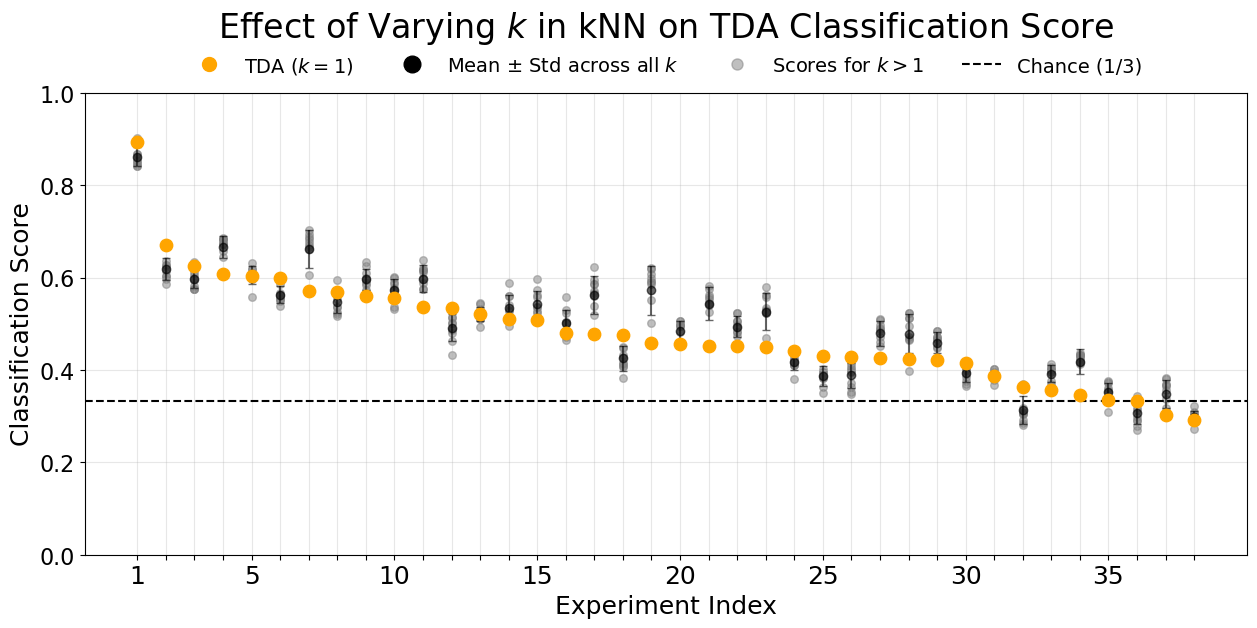

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# ---- font controls ----
legend_font_size = 14
font_size = 30
axes_titlesize = 20
axes_labelsize = 18
xtick_labelsize = 18
ytick_labelsize = 16
figure_titlesize = 24

plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": axes_titlesize,
    "axes.labelsize": axes_labelsize,
    "xtick.labelsize": xtick_labelsize,
    "ytick.labelsize": ytick_labelsize,
    "legend.fontsize": legend_font_size,
    "figure.titlesize": figure_titlesize,
})

# =====================================================================
# 1. Data Preparation
# Assuming 'MD_scores_table_3class' is your DataFrame from the loop
# Columns should be: ['Mouse', 'Date', 'k', 'TDA Score']
# =====================================================================

# Pivot the table so each row is a unique Mouse-Date, and columns are the k values (1 through 10)
pivot_df = MD_scores_table_3class.pivot(
    index=['Mouse', 'Date'], 
    columns='k', 
    values='TDA Score'
).reset_index()

# Identify the columns that represent k values
k_cols = [col for col in pivot_df.columns if isinstance(col, (int, float)) or str(col).isdigit()]

# Sort experiments by the performance of our chosen k=1 in descending order
pivot_df = pivot_df.sort_values(by=1, ascending=False).reset_index(drop=True)

# Calculate Mean and Std Deviation across all k values for each experiment
pivot_df['Mean_k'] = pivot_df[k_cols].mean(axis=1)
pivot_df['Std_k'] = pivot_df[k_cols].std(axis=1)


# =====================================================================
# 2. Plotting
# =====================================================================

# Create a single panel
fig, ax = plt.subplots(figsize=(15, 6))

ax.set_title("Effect of Varying $k$ in kNN on TDA Classification Score", fontsize=figure_titlesize, pad=40)
ax.set_ylabel("Classification Score", fontsize=axes_labelsize)
ax.set_xlabel("Experiment Index", fontsize=axes_labelsize)

# Formatting axes
ax.set_ylim(0, 1)
ax.grid(axis="both", linestyle="-", alpha=0.3)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Plot Chance Line
chance_3class = 1 / 3
ax.axhline(y=chance_3class, color="black", linestyle="--", label="Chance")

# X-axis setup
experiments = pivot_df.index
x_ticks = np.arange(len(experiments))
tick_labels = [str(i + 1) if (i == 0 or (i + 1) % 5 == 0) else "" for i in range(len(experiments))]

ax.set_xticks(x_ticks)
ax.set_xticklabels(tick_labels, rotation=0)

# Iterate through each experiment to plot the spread of k > 1
for i, row in pivot_df.iterrows():
    # Get all scores for this experiment EXCEPT k=1
    other_ks = [col for col in k_cols if col != 1]
    scores = row[other_ks].values
    x_values = [i] * len(scores)
    
    if i == 0:
        ax.scatter(x_values, scores, color="gray", alpha=0.5, s=30, label="Scores for $k > 1$")
    else:
        ax.scatter(x_values, scores, color="gray", alpha=0.5, s=30)

# Plot Mean +/- Std Dev error bars
ax.errorbar(
    x_ticks, 
    pivot_df['Mean_k'], 
    yerr=pivot_df['Std_k'], 
    fmt='o', 
    color='black', 
    capsize=3, 
    alpha=0.6, 
    label='Mean $\pm$ Std across all $k$',
    zorder=4
)

# Plot k=1 specifically on top (zorder=5) to highlight it
ax.scatter(x_ticks, pivot_df[1], color="orange", marker="o", s=80, label="TDA ($k=1$)", zorder=5)

# Shared legend mapping exactly to the plotted elements
legend_handles = [
    Line2D([0], [0], marker="o", color="orange", linestyle="None", markersize=10, label="TDA ($k=1$)"),
    Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=12, label="Mean $\pm$ Std across all $k$"),
    Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=8, alpha=0.5, label="Scores for $k > 1$"),
    Line2D([0], [0], color="black", linestyle="--", label="Chance (1/3)"),
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.12), # Places legend nicely above the plot, below title
    fontsize=legend_font_size,
)

plt.savefig("k_parameter_stability.pdf", format="pdf", bbox_inches="tight")
plt.show()